# FIFA World Cup 2026 — Group Breakdown

Phase-1 validation report. Reads `data/worldcup.db` and renders every group as
**4-column small multiples**: each panel shows the current **standings table**
(GP, W, D, L, GF, GA, GD, Pts) plus the group's **chronological schedule**
(local + UTC time, venue/city, weather, projected winner & win %, and the final
score once a match is played).

Data is refreshed daily by the GitHub Actions pipeline. Early-tournament gaps
(missing predictions/weather) render as blanks, never errors.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

%matplotlib inline
import sqlite3
import pandas as pd
from IPython.display import HTML, display

import report
from config import DB_PATH

# Print-friendly table styling for DataFrame displays in this notebook.
display(HTML("""
<style>
table.dataframe { border-collapse: collapse !important; border: 2px solid rgba(0,0,0,0.2) !important; }
table.dataframe td, table.dataframe th { border: 1.5px solid rgba(0,0,0,0.15) !important; }
table.dataframe thead th { background-color: #f0f0f0 !important; font-weight: bold !important; }
</style>
"""))

print("Database:", DB_PATH)

Database: /Users/marcalexander/projects/ai_orchestrator_claude/world_cup_soccer_2026/data/worldcup.db


## Data freshness — recent load runs

In [2]:
conn = sqlite3.connect(DB_PATH)
display(pd.read_sql(
    """SELECT run_id, run_type, started_at, cutoff_date,
              fixtures_upserted, status, notes
       FROM load_run ORDER BY run_id DESC LIMIT 5""", conn))

counts = {t: pd.read_sql(f"SELECT COUNT(*) n FROM {t}", conn)["n"][0]
          for t in ["team", "venue", "fixture", "standing", "prediction", "weather"]}
print("row counts:", counts)
print("finished fixtures:", pd.read_sql("SELECT COUNT(*) n FROM fixture WHERE is_finished=1", conn)["n"][0])

,run_id,run_type,started_at,cutoff_date,fixtures_upserted,status,notes
0,10,incremental,2026-06-16T06:39:46.482242+00:00,2026-06-15,72,ok,finished=12; predictions_probed=10; new_predic...
1,9,incremental,2026-06-16T06:38:51.435062+00:00,2026-06-15,72,ok,finished=12; predictions_probed=10; new_predic...
2,8,incremental,2026-06-16T06:32:03.858827+00:00,2026-06-15,72,ok,finished=12; predictions_probed=10; new_predic...
3,7,incremental,2026-06-16T06:31:16.768889+00:00,2026-06-15,72,ok,finished=12; predictions_probed=10; new_predic...
4,6,incremental,2026-06-16T06:27:02.493424+00:00,2026-06-15,72,ok,finished=12; predictions_probed=10; new_predic...


row counts: {'team': 48, 'venue': 16, 'fixture': 72, 'standing': 48, 'prediction': 31, 'weather': 72}
finished fixtures: 12


## Group panels (4 × N small multiples)

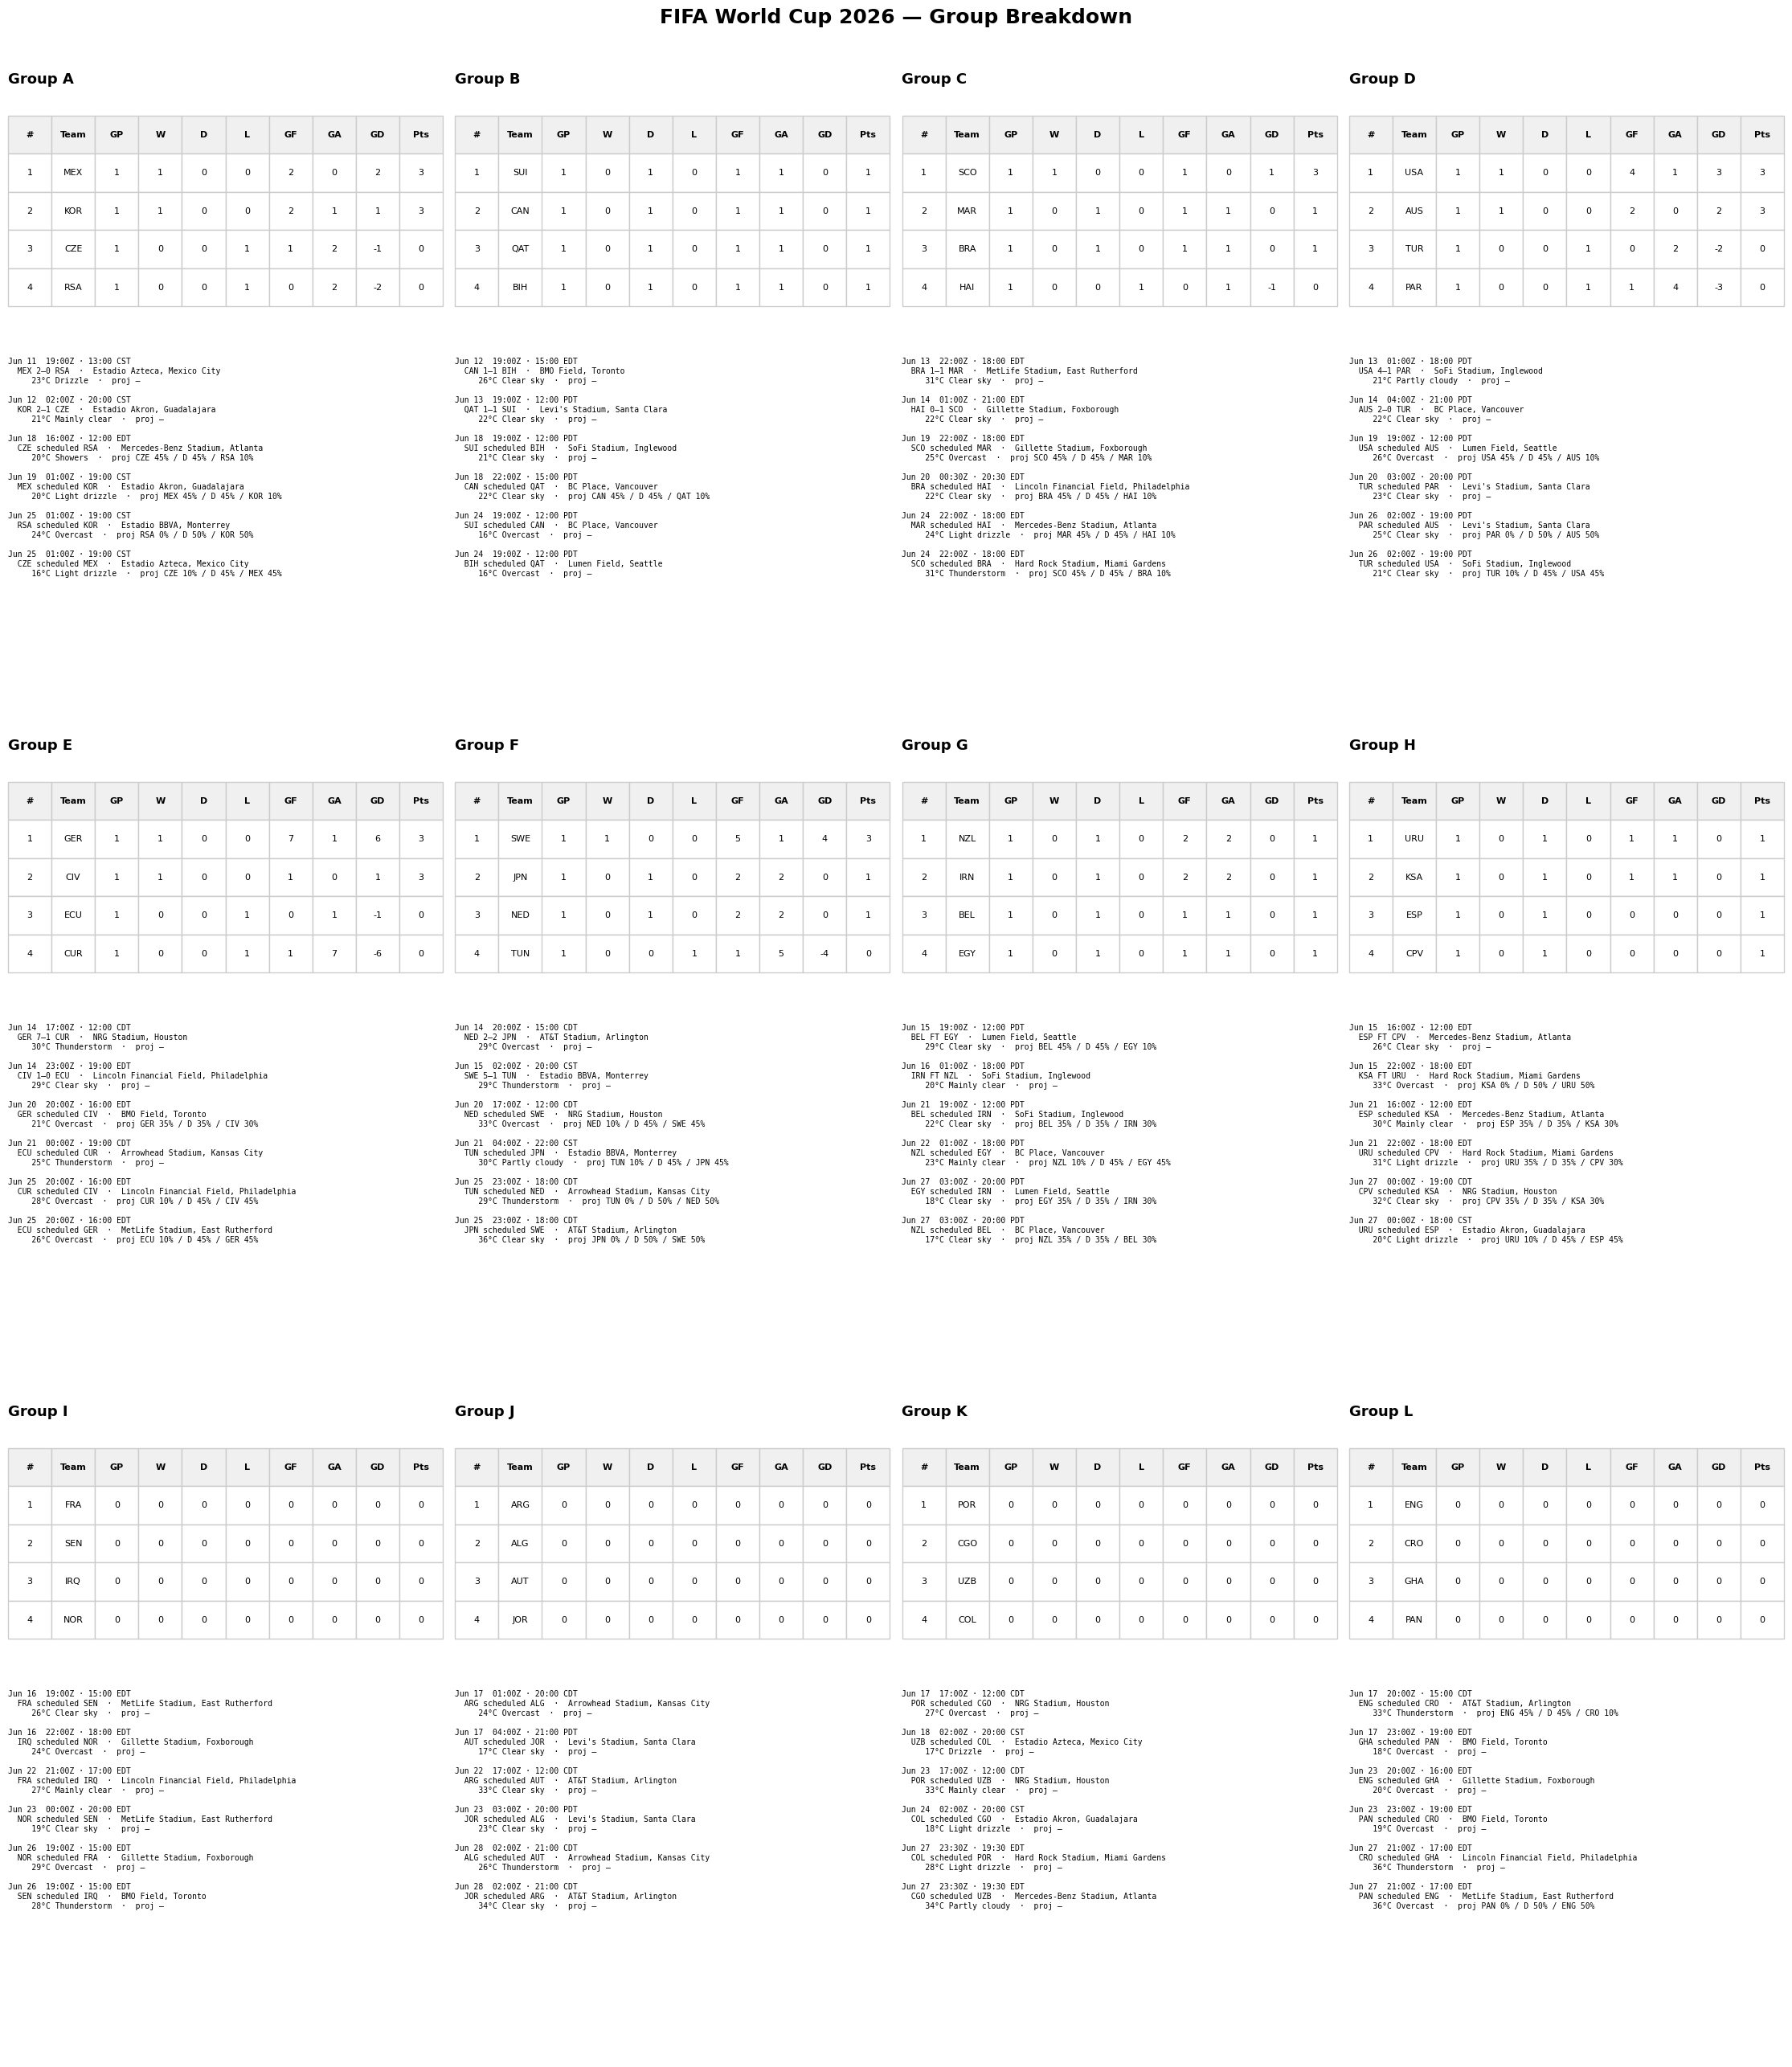

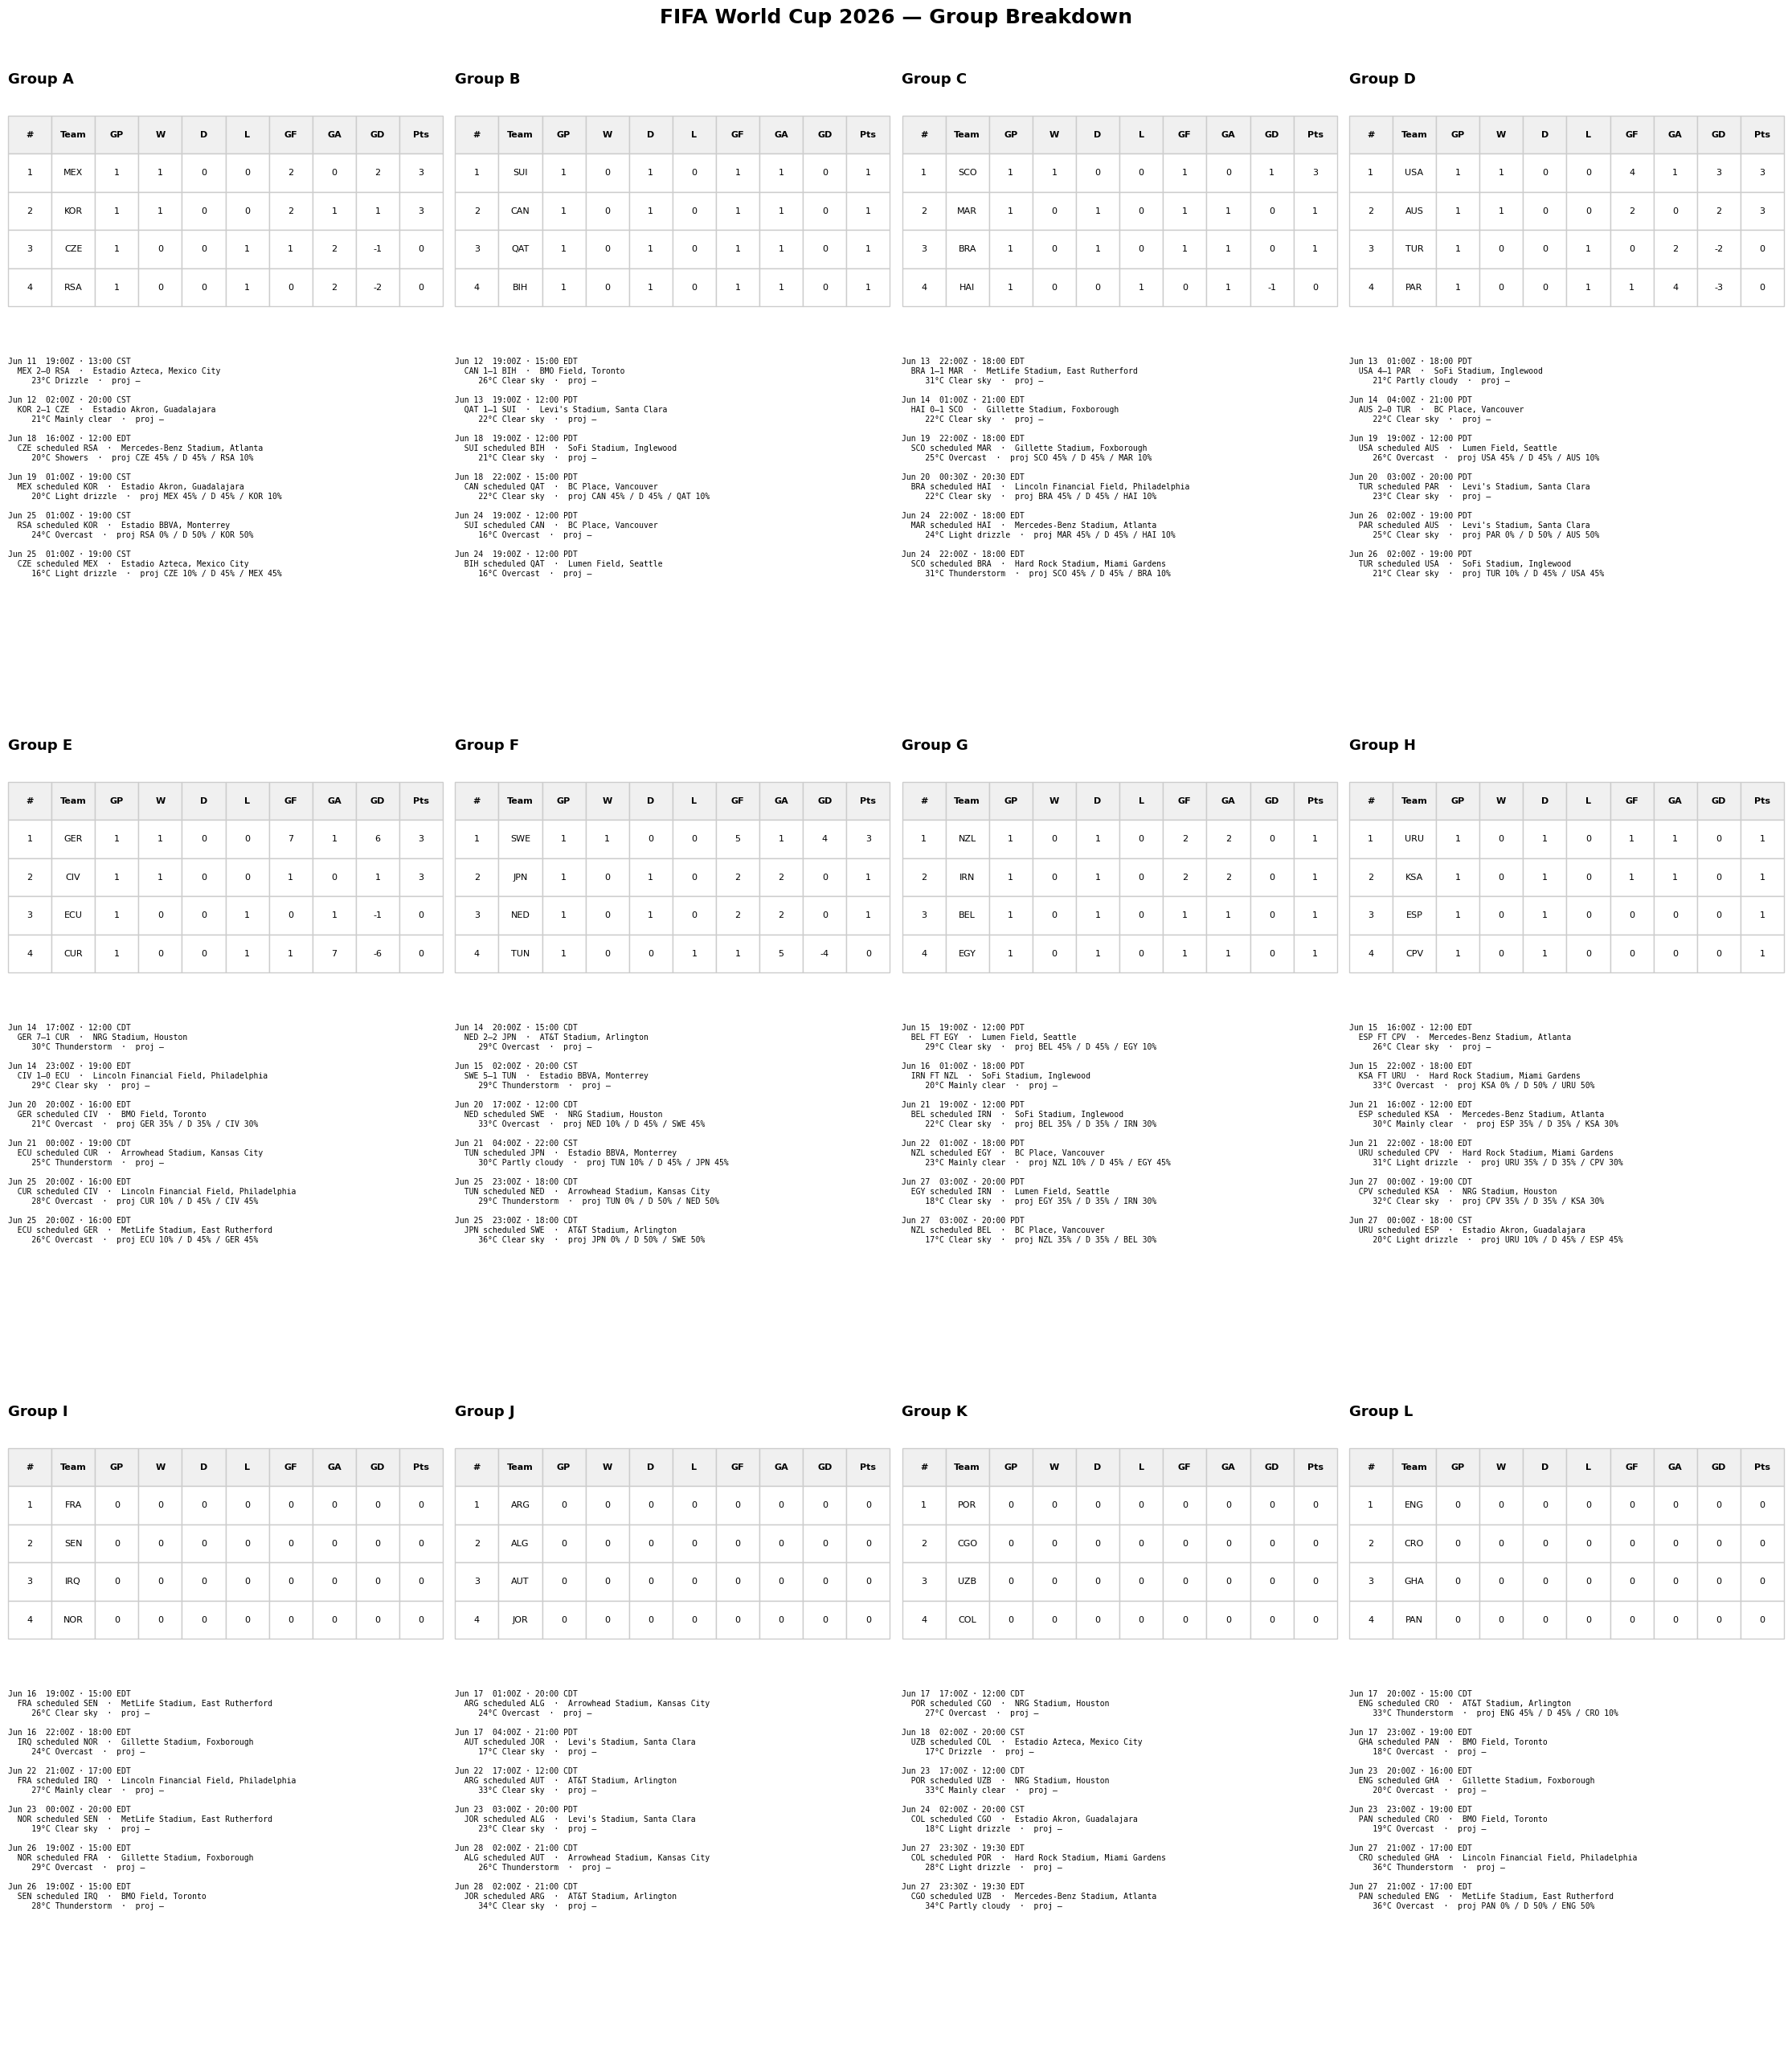

In [3]:
fig = report.build_group_breakdown_figure(conn)
fig  # render inline